<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/4.3-training-building-a-cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Implementación de Unidad Recurrente Bidireccional con Compuerta (BiGRU).

En este notebook vamos a levar a cabo el uso de una *Bidirectional gated recurrent Unit* por sus siglas en ingles *BiGRU*, es una variante avanzada de las Redes Neuronales Recurrentes (RNN) que mejora el procesamiento de secuencias al analizar los datos en ambas direcciones: de principio a fin (hacia adelante) y de fin a principio (hacia atrás). Esta arquitectura combina dos capas de Unidades Recurrentes con Compuerta (GRU) independientes para capturar el contexto tanto pasado como futuro de cada elemento en una secuencia. Para sacar provecho de los canales que conservan la dimension temporal en nuestros tensores, es decir los canales correspondientes al delta del mel-spec y a espectrograma *cohclear db*.

Cabe destacar que, para las primeros bloques de la arquitectura de la Red Neuronal, se usan unidades estandar del tipo Convolusional, de manera que, nuestra red de manera general tendrala suiguiente estructura:

## 2. Monitoreo con Weights & Biases

Para optimizar el rendimiento de nuestra arquitectura CBGRU (CNN + BiGRU), integramos Weights & Biases (W&B) como plataforma central de experimentación. En modelos híbridos complejos, es crítico entender cómo interactúan las capas convolucionales y las recurrentes.

**Seguimiento (Tracking)**: Registro en tiempo real de métricas (pérdida, precisión), hiperparámetros y consumo de hardware (GPU/CPU).

**Visualización**: Tableros interactivos para comparar ejecuciones y analizar el rendimiento del modelo.

**Artefactos**: Control de versiones para datasets y modelos, garantizando la trazabilidad y reproducibilidad.

**Barrido (Sweeps)**: Automatización de la búsqueda de los mejores hiperparámetros para optimizar el modelo.

El objetivo es:

* Registrar cada ejecución (hiperparámetros + métricas + artefactos)

* Seleccionar el mejor punto de control usando solo la validación.

* Evaluar una sola vez al final para evitar la fuga de datos de las pruebas.

* Constatar la evolución de los modelos y sus diferentes arquitecturas.

* Obener un modelo final para su inferencia y despliegue a partir de la verificación de su rendimiento despúes de la respectiva experimentación.


### 1. Imports y configuración base


In [1]:
# Imports
#------------------------------------------------------------------------------------------
import os
import copy
import numpy as np
import torch
import xgboost as xgb
import random as random
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import time
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torchaudio import transforms as T
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score,
)
from google.colab import drive
from tqdm import tqdm
from collections import Counter

In [3]:
# ─── Instalación de Weights & Biases ────────────────────────────────
# Descomenta las líneas siguientes si wandb no está instalado en tu entorno:
!pip install wandb -q

# Para autenticarte (solo la primera vez por sesión de Colab):
import wandb; wandb.login()

# USE_WANDB se define en la celda de configuración más abajo.
# Déjalo en False para ejecutar sin tracking remoto.

True

In [4]:
# Semilla y runtime
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


### 2. Carga de tensores desde Drive (train/val/test)

Los archivos `.pt` generados en el notebook 3.2 contienen un diccionario con `x`, `y`,
metadatos y el mapeo de clases. Ajusta `BASE_DIR_TENSOR` según tu ruta local/Drive.


In [5]:
#drive.mount('/content/drive')
#! cp -r /content/drive/MyDrive/split_pytorch_tensors /content/split_pytorch_tensors

Mounted at /content/drive


In [6]:
BASE_DIR_TENSOR = '/content/split_pytorch_tensors'
BATCH_SIZE = 32

SPLIT_FILES = {
    'train': 'train_tensors.pt',
    'val': 'val_tensors.pt',
    'test': 'test_tensors.pt',
}

def load_pack(split_name: str):
    path = os.path.join(BASE_DIR_TENSOR, SPLIT_FILES[split_name])
    if not os.path.exists(path):
        raise FileNotFoundError(f'No existe el archivo: {path}')
    return torch.load(path, map_location='cpu', weights_only=False)

# Cargamos lo packs en variables aun no son tensores puros
train_pack = load_pack('train')
val_pack = load_pack('val')
test_pack = load_pack('test')

# Verificamos las clases del diccionario dentro del pack
class_to_idx = train_pack['class_to_idx']
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]
print('Clases:', class_names)
print('Shape train:', tuple(train_pack['x'].shape))

Clases: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Shape train: (7422, 3, 60, 51)


### Estrategia de normalización y augmentation

**Normalización:**  
Los tensores provienen del notebook `3.2` y ya fueron normalizados con **z-score por muestra y canal** (`zscore_per_channel`). No se aplica una segunda normalización a nivel de dataset para evitar doble normalización.

**Augmentation online (desactivado por defecto):**  
El notebook `3.2` ya añadió muestras extra de `surprised` con **ruido** y **shift temporal** durante la exportación (augmentación *offline*). Por eso `augment=False` es el valor por defecto en `build_dataloaders`: la augmentación offline ya aporta robustez sin el riesgo de distorsionar demasiado las entradas.  
Si se desea augmentación online adicional, se puede activar `augment=True`; en ese caso se aplica exclusivamente **SpecAugment** (FrequencyMasking + TimeMasking), más un pequeño ruido gaussiano opcional.

**Early stopping y scheduler:**  
Se usa **macro-F1** como criterio en lugar de `val_loss`, ya que es más informativo para datasets desbalanceados y refleja mejor el objetivo de clasificación equitativa entre clases.


In [7]:
class TensorPackDataset(Dataset):
  def __init__(self, pack, augment=False):
      self.x = pack['x'].float() # [N, 3, n_mels, targetframes]
      self.y = pack['y'].long()  # len(N)
      self.augment = augment

      # Definimos las transformaciones de SpecAugment
      # Ajustar n_freq_masks y n_time_masks según el tamaño (60x51)
      if augment:
          self.spec_aug = nn.Sequential(
              T.FrequencyMasking(freq_mask_param=4), # Enmascara hasta 4 bins de mel
              T.TimeMasking(time_mask_param=2)       # Enmascara hasta 2 frames de tiempo
          )

  def __len__(self):
      return self.y.shape[0]

  def __getitem__(self, idx):
      x = self.x[idx]
      y = self.y[idx]

      if self.augment:
          # SpecAugment espera [batch, channel, freq, time] o [channel, freq, time]
          # Aplicamos la misma máscara a los 3 canales (Mel spec, delta, Cochlear)
          x = self.spec_aug(x)

          # Opcional: Pequeño ruido gaussiano
          if random.random() < 0.5:
              x = x + 0.01 * torch.randn_like(x)

      return x, y

In [8]:
class EarlyStopping:
    """Early stopping configurable para minimizar (val_loss) o maximizar (val_f1)."""
    def __init__(self, patience=5, min_delta=0.0, mode="min"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode  # "min" para loss, "max" para F1
        self.best = None
        self.counter = 0

    def step(self, metric):
        """Devuelve True cuando se debe detener el entrenamiento."""
        if self.best is None:
            self.best = metric
            return False
        improved = (metric > self.best + self.min_delta) if self.mode == "max" \
                   else (metric < self.best - self.min_delta)
        if improved:
            self.best = metric
            self.counter = 0
            return False
        self.counter += 1
        print(f"Early Stopping: {self.counter}/{self.patience} (best={self.best:.4f})")
        return self.counter >= self.patience


In [9]:
# Solo aumentamos el set de TRAIN. Val y Test deben quedar puros.
def build_dataloaders(batch_size=BATCH_SIZE):
    pin = torch.cuda.is_available()
    # Valor por defecto: augment= False
    train_ds = TensorPackDataset(train_pack, augment=False)
    val_ds = TensorPackDataset(val_pack, augment=False)
    test_ds = TensorPackDataset(test_pack, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = build_dataloaders()


### 3. Definición de la CNN


In [ ]:
class EmotionCGRU(nn.Module):
    def __init__(self, num_classes, classifier_dropout=0.5):
        super().__init__()

        self.cnn = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 60 -> 30, Tiempo: 51 -> 51

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 30 -> 15, Tiempo: 51 -> 51
            nn.Dropout2d(0.1),

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.05),
            # Forzamos frecuencia a 8, mantenemos Tiempo intacto (None o 51)
            nn.AdaptiveAvgPool2d((8, None))
        )

        # 128 canales * 8 bins de frecuencia = 1024
        self.gru_input_size = 128 * 8

        self.bigru = nn.GRU(
            input_size=self.gru_input_size,
            hidden_size=128,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(classifier_dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Entrada: (Batch, 3, 60, 51)
        x = self.cnn(x) # Salida: (Batch, 128, 8, 51)

        batch_size, channels, freq, time = x.size()

        # Formatear para GRU: (Batch, Tiempo, Features)
        # 1. Permutamos a (Batch, Tiempo, Canales, Frecuencia) -> (Batch, 51, 128, 8)
        x = x.permute(0, 3, 1, 2).contiguous()
        # 2. Aplanamos a (Batch, 51, 1024)
        x = x.view(batch_size, time, channels * freq)

        gru_out, _ = self.bigru(x)
        # Promedio temporal de las salidas de la GRU
        x = gru_out.mean(dim=1)
        return self.classifier(x)

In [10]:
# --- Configuración de W&B y matriz de experimentos -----------------------------
# Establece USE_WANDB = True para registrar experimentos en Weights & Biases.
# Requiere wandb instalado (!pip install wandb -q) y autenticado (wandb.login()).
USE_WANDB      = True               # ← cambiar a True para activar tracking
WANDB_PROJECT  = "the-color-of-emotions"
WANDB_GROUP    = "cnn-cgru-batch32"  # agrupa los cuatro experimentos en la misma vista

# --- Hiperparámetros que son fijos en los cuatro experimentos-------------------
# Baseline confirmado: BATCH_SIZE=32, augment=False (sin SpecAugment online),

EPOCHS              = 50
LABEL_SMOOTHING     = 0.05
MAX_GRAD_NORM       = 1.0
EARLY_STOP_PATIENCE = 8    # patience mayor para que los drops de LR tomen efecto, no usar un valor menor a 4

# Directorio local para guardar los mejores checkpoints por corrida
CHECKPOINT_DIR = '/content/checkpoints_cnn'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# --- Matriz de experimentos (4 ejecuciones) ------------------------------------
# Scheduler fijo: ReduceLROnPlateau(mode='max', factor=0.5, patience=2) sobre val macro-F1.
# Gradient clipping: max_norm=1.0.  Label smoothing: 0.05.
RUN_MATRIX = [
    # Run 1 — baseline fuerte: LR conservador, dropout estándar, pesos de clase
    {
        "run_name": "run1_lr3e4_wd1e3_do05_cw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": True,
    },
    # Run 2 — LR más alto: explorar convergencia más rápida
    {
        "run_name": "run2_lr5e4_wd1e3_do05_cw",
        "lr": 5e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": True,
    },
    # Run 3 — dropout reducido: menos regularización en el clasificador
    {
        "run_name": "run3_lr3e4_wd1e3_do03_cw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.3,
        "use_class_weights": True,
    },
    # Run 4 — diagnóstico: sin pesos de clase (mide impacto del balanceo)
    {
        "run_name": "run4_lr3e4_wd1e3_do05_nocw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": False,
    },
]


### 4. Entrenamiento y validación


In [11]:
# TRAIN
#-------------------------------------------------------------------------------
# Calcular pesos de clase: total / (n_clases * counts)
# Esto da más peso a las clases con menos muestras.
''''surprised' tiene muestras extra desde la exportación offline, por lo que su peso
    resultante será menor que otras clases sub-representadas.'''

y_train_cpu = train_pack['y'].numpy()
label_counts = Counter(y_train_cpu)
total_samples = len(y_train_cpu)
num_classes = len(class_names)

class_weights = []
for i in range(num_classes):
    count = label_counts.get(i, 1)
    weight = total_samples / (num_classes * count)
    class_weights.append(weight)

class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"Pesos calculados para CrossEntropyLoss: {class_weights}")


def train_one_epoch(model, loader, criterion, optimizer, device, epoch=None, max_grad_norm=1.0):
    model.train()
    running_loss = 0.0
    running_correct = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [train]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        # Gradient clipping para estabilizar el entrenamiento del GRU
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    return epoch_loss, epoch_acc


# VAL
#-------------------------------------------------------------------------------
@torch.no_grad()
def evaluate(model, loader, criterion, device, epoch=None):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    all_preds, all_targets = [], []

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [val]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_targets.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    # Macro-F1: métrica clave para datasets desbalanceados con objetivo de clasificación equitativa
    epoch_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    return epoch_loss, epoch_acc, epoch_f1


# TEST / PREDICCIONES
#-------------------------------------------------------------------------------
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for inputs, labels in loader:
        outputs = model(inputs.to(device))
        all_preds.append(outputs.argmax(1).cpu().numpy())
        all_targets.append(labels.numpy())
    return np.concatenate(all_targets), np.concatenate(all_preds)


Pesos calculados para CrossEntropyLoss: [0.9000727625515401, 0.9000727625515401, 0.9000727625515401, 0.9000727625515401, 0.9638961038961039, 0.9000727625515401, 2.4543650793650795]


In [ ]:
# ─── Entrenamiento multi-experimento con W&B ──────────────────────────────────
all_run_results = []

for run_cfg in RUN_MATRIX:
    run_name           = run_cfg["run_name"]
    lr                 = run_cfg["lr"]
    weight_decay       = run_cfg["weight_decay"]
    classifier_dropout = run_cfg["classifier_dropout"]
    use_class_weights  = run_cfg["use_class_weights"]

    print(f"\n{'='*70}")
    print(f"  INICIANDO: {run_name}")
    print(f"  lr={lr}  wd={weight_decay}  dropout={classifier_dropout}  class_weights={use_class_weights}")
    print(f"{'='*70}\n")

    # Reproducibilidad por ejecucion
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)

    # Dataloaders frescos para cada ejecucion
    train_loader, val_loader, test_loader = build_dataloaders()

    # Modelo con el dropout del clasificador según la ejecucion
    model = EmotionCGRU(num_classes=len(class_names), classifier_dropout=classifier_dropout).to(device)

    # Función de pérdida
    criterion_weights = class_weights_tensor if use_class_weights else None
    criterion = nn.CrossEntropyLoss(weight=criterion_weights, label_smoothing=LABEL_SMOOTHING)

    # Optimizador y scheduler
    optimizer    = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler    = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    early_stopper = EarlyStopping(patience=EARLY_STOP_PATIENCE, min_delta=1e-4, mode='max')

    # Inicializar W&B
    if USE_WANDB:
        import wandb
        wandb.init(
            project=WANDB_PROJECT,
            group=WANDB_GROUP,
            name=run_name,
            config={
                "lr":                 lr,
                "weight_decay":       weight_decay,
                "classifier_dropout": classifier_dropout,
                "use_class_weights":  use_class_weights,
                "label_smoothing":    LABEL_SMOOTHING,
                "batch_size":         BATCH_SIZE,
                "epochs":             EPOCHS,
                "early_stop_patience": EARLY_STOP_PATIENCE,
                "max_grad_norm":      MAX_GRAD_NORM,
                "augment_online":     False,
                "model":              "EmotionCGRU",
            },
        )

    best_val_f1 = 0.0
    best_epoch  = 0
    best_state  = copy.deepcopy(model.state_dict())

    for epoch in range(1, EPOCHS + 1):
        start = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            epoch=epoch, max_grad_norm=MAX_GRAD_NORM,
        )
        val_loss, val_acc, val_f1 = evaluate(
            model, val_loader, criterion, device, epoch=epoch,
        )

        scheduler.step(val_f1)
        current_lr = optimizer.param_groups[0]['lr']
        elapsed = time.time() - start

        print(
            f"[{time.strftime('%H:%M:%S')}] Epoca {epoch:02d}/{EPOCHS:02d} | "
            f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"Val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
            f"lr {current_lr:.1e} | Time {elapsed:.1f}s"
        )

        if USE_WANDB:
            wandb.log({
                "train_loss":   train_loss,
                "train_acc":    train_acc,
                "val_loss":     val_loss,
                "val_acc":      val_acc,
                "val_macro_f1": val_f1,
                "lr":           current_lr,
            }, step=epoch)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch  = epoch
            best_state  = copy.deepcopy(model.state_dict())
            ckpt_path   = os.path.join(CHECKPOINT_DIR, f"{run_name}_best.pth")
            torch.save(best_state, ckpt_path)

        if early_stopper.step(val_f1):
            print(f"Early stopping en epoch {epoch} (best val_f1={best_val_f1:.4f})")
            break

    # ── Evaluación en test (una sola vez, con el mejor modelo por val_f1) ──────
    model.load_state_dict(best_state)
    y_true, y_pred = get_predictions(model, test_loader, device)
    test_f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    test_acc = accuracy_score(y_true, y_pred)

    print(f"\n--- RESULTADO TEST [{run_name}] ---")
    print(f"  best_epoch={best_epoch}  best_val_f1={best_val_f1:.4f}")
    print(f"  test_macro_f1={test_f1:.4f}  test_acc={test_acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax_cm, cmap='Blues', xticks_rotation=45, values_format='d')
    ax_cm.set_title(f"Confusion Matrix — {run_name}")
    plt.tight_layout()
    plt.show()

    if USE_WANDB:
        # Guardar y loggear el checkpoint como artefacto
        artifact = wandb.Artifact(name=f"model_{run_name}", type="model")
        artifact.add_file(ckpt_path)
        wandb.log_artifact(artifact)

        # Métricas y artefactos de test
        report_dict = classification_report(
            y_true, y_pred, target_names=class_names, output_dict=True)
        wandb.log({
            "test_macro_f1":       test_f1,
            "test_acc":            test_acc,
            "confusion_matrix":    wandb.Image(fig_cm),
            "classification_report": wandb.Table(
                columns=["class", "precision", "recall", "f1-score", "support"],
                data=[
                    [c,
                     report_dict[c]["precision"],
                     report_dict[c]["recall"],
                     report_dict[c]["f1-score"],
                     int(report_dict[c]["support"])]
                    for c in class_names
                ],
            ),
        })
        wandb.finish()

    all_run_results.append({
        "run_name":      run_name,
        "best_val_f1":   round(best_val_f1, 4),
        "best_epoch":    best_epoch,
        "test_macro_f1": round(test_f1, 4),
        "test_acc":      round(test_acc, 4),
    })
    plt.close('all')


[23:35:50] Epoca 01 / 50 | Train loss 1.7416 acc 0.2964 | Val loss 1.7146 acc 0.3002 f1 0.2341 | Time 4.2s


[23:35:54] Epoca 02 / 50 | Train loss 1.5625 acc 0.3733 | Val loss 1.6739 acc 0.3254 f1 0.2623 | Time 4.5s


[23:35:58] Epoca 03 / 50 | Train loss 1.5110 acc 0.3972 | Val loss 1.6105 acc 0.3577 f1 0.3155 | Time 4.0s


[23:36:03] Epoca 04 / 50 | Train loss 1.4588 acc 0.4299 | Val loss 1.5633 acc 0.4007 f1 0.3752 | Time 4.8s


[23:36:07] Epoca 05 / 50 | Train loss 1.4006 acc 0.4483 | Val loss 1.5677 acc 0.4067 f1 0.3784 | Time 4.2s


...

[23:37:47] Epoca 29 / 50 | Train loss 0.7964 acc 0.7817 | Val loss 1.3896 acc 0.5694 f1 0.5747 | Time 4.2s
Early Stopping: 2/5 (best=0.5924)


[23:37:52] Epoca 30 / 50 | Train loss 0.7892 acc 0.7816 | Val loss 1.3891 acc 0.5754 f1 0.5859 | Time 4.1s
Early Stopping: 3/5 (best=0.5924)


[23:37:56] Epoca 31 / 50 | Train loss 0.7668 acc 0.7926 | Val loss 1.3837 acc 0.5754 f1 0.5836 | Time 4.2s
Early Stopping: 4/5 (best=0.5924)


[23:38:00] Epoca 32 / 50 | Train loss 0.7620 acc 0.8007 | Val loss 1.3850 acc 0.5837 f1 0.5905 | Time 4.2s
Early Stopping: 5/5 (best=0.5924)
Early stopping en epoch 32 (best val_f1=0.5924)
Mejor F1 macro en validación: 0.5924
              precision    recall  f1-score   support

       angry       0.76      0.80      0.78       149
     disgust       0.57      0.57      0.57       149
     fearful       0.56      0.59      0.57       149
       happy       0.62      0.46      0.53       149
     neutral       0.55      0.73      0.63       143
         sad       0.60      0.53      0.56       149
   surprised       0.67      0.50      0.57        24

    accuracy                           0.61       912
   macro avg       0.62      0.60      0.60       912
weighted avg       0.61      0.61      0.61       912


F1-score por clase:


,clase,f1_score
0,angry,0.780328
1,disgust,0.568562
2,fearful,0.573290
3,happy,0.530769
4,neutral,0.628399
5,sad,0.564286
6,surprised,0.571429


### 5. Resumen de experimentos y evaluación final


              precision    recall  f1-score   support

       angry       0.76      0.80      0.78       149
     disgust       0.57      0.57      0.57       149
     fearful       0.56      0.59      0.57       149
       happy       0.62      0.46      0.53       149
     neutral       0.55      0.73      0.63       143
         sad       0.60      0.53      0.56       149
   surprised       0.67      0.50      0.57        24

    accuracy                           0.61       912
   macro avg       0.62      0.60      0.60       912
weighted avg       0.61      0.61      0.61       912

Matriz de confusion plana: 

[[0.13 0.01 0.01 0.01 0.   0.   0.  ]
 [0.02 0.09 0.02 0.01 0.01 0.02 0.  ]
 [0.   0.02 0.1  0.01 0.02 0.02 0.  ]
 [0.01 0.02 0.02 0.08 0.03 0.01 0.  ]
 [0.   0.01 0.   0.01 0.11 0.01 0.  ]
 [0.   0.01 0.03 0.   0.03 0.09 0.  ]
 [0.   0.   0.   0.   0.   0.   0.01]]


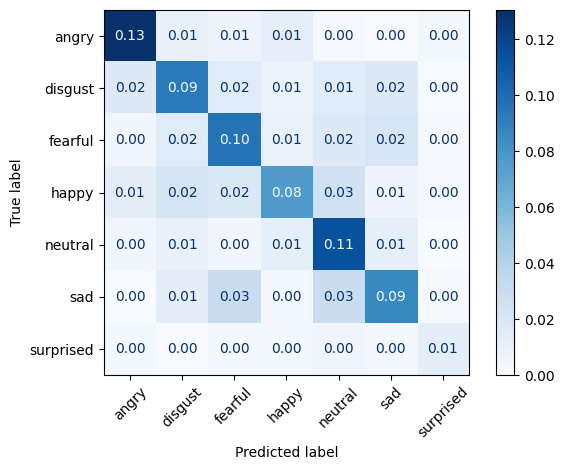

In [ ]:
# ─── Tabla resumen de todas las corridas ─────────────────────────────────────
summary_df = pd.DataFrame(all_run_results)
summary_df = summary_df.sort_values("best_val_f1", ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("  RESUMEN FINAL DE EXPERIMENTOS")
print("="*70)
print(summary_df.to_string(index=False))
display(summary_df)


## Modelos tradicionales de ML con Grid Search

Se entrenan **Random Forest** y **XGBoost** con búsqueda de hiperparámetros usando
`GridSearchCV` con `PredefinedSplit` para respetar la partición train/val sin filtrar
el set de test. Antes del entrenamiento se aplica **SMOTE** exclusivamente sobre el
conjunto de entrenamiento para balancear la clase minoritaria `surprised`.


In [ ]:
def pack_to_numpy(pack):
    x = pack['x'].float().reshape(pack['x'].shape[0], -1).numpy()
    y = pack['y'].numpy()
    return x, y

X_train, y_train = pack_to_numpy(train_pack)
X_val, y_val = pack_to_numpy(val_pack)
X_test, y_test = pack_to_numpy(test_pack)
X_train_val = np.concatenate([X_train, X_val], axis=0)
y_train_val = np.concatenate([y_train, y_val], axis=0)


print(f"Muestras por clase:")
for cls, idx in sorted(class_to_idx.items(), key=lambda kv: kv[1]):
    print(f"  {cls:12s} (idx={idx}): {(y_train == idx).sum()}")

# -1 = train, 0 = val (PredefinedSplit usa índice de fold)
test_fold = np.concatenate([
    -1 * np.ones(len(X_train), dtype=int),
     np.zeros(len(X_val), dtype=int)
])
predefined_split = PredefinedSplit(test_fold)
print(f"\nTamaño total train+val para GridSearchCV: {len(X_train_val)}")
print(f"(train={len(X_train)}, val={len(X_val)}, test={len(X_test)} — test NO entra en GridSearch)")


Muestras por clase:
  angry        (idx=0): 1178
  disgust      (idx=1): 1178
  fearful      (idx=2): 1178
  happy        (idx=3): 1178
  neutral      (idx=4): 1100
  sad          (idx=5): 1178
  surprised    (idx=6): 432

Tamaño total train+val para GridSearchCV: 8258
(train=7422, val=836, test=912 — test NO entra en GridSearch)


In [ ]:
# ── Random Forest con Grid Search ────────────────────────────────────────────
param_grid_rf = {
    'n_estimators': [20, 60],
    'max_depth': [20, None],
    'min_samples_split': [2, 6],
    'min_samples_leaf': [1, 7],
    'max_features': ['log2'],
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
grid_rf = GridSearchCV(
    rf,
    param_grid=param_grid_rf,
    cv=predefined_split,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
grid_rf.fit(X_train_val, y_train_val)

print('RF — Mejores parámetros:', grid_rf.best_params_)
print('RF — Mejor f1_macro (val):', grid_rf.best_score_)


Fitting 1 folds for each of 16 candidates, totalling 16 fits
RF — Mejores parámetros: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 7, 'min_samples_split': 2, 'n_estimators': 60}
RF — Mejor f1_macro (val): 0.33904274294423553


=== Random Forest — Evaluación en Test ===
              precision    recall  f1-score   support

       angry       0.62      0.62      0.62       149
     disgust       0.33      0.26      0.29       149
     fearful       0.28      0.12      0.17       149
       happy       0.40      0.34      0.37       149
     neutral       0.34      0.49      0.40       143
         sad       0.48      0.48      0.48       149
   surprised       0.10      0.42      0.16        24

    accuracy                           0.38       912
   macro avg       0.36      0.39      0.35       912
weighted avg       0.40      0.38      0.38       912



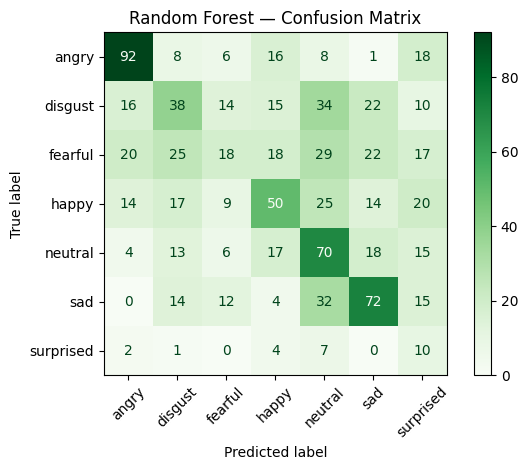

In [ ]:
best_rf = RandomForestClassifier(**grid_rf.best_params_, random_state=42, class_weight='balanced', n_jobs=-1)
best_rf.fit(X_train_val, y_train_val)
y_pred_rf = best_rf.predict(X_test)
print('=== Random Forest — Evaluación en Test ===')
print(classification_report(y_test, y_pred_rf, target_names=class_names))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=class_names).plot(cmap='Greens', xticks_rotation=45)
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# ── XGBoost con Grid Search ───────────────────────────────────────────────────
param_grid_xgb = {
    'n_estimators': [30],
    'max_depth': [3],
    'learning_rate': [0.01],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(class_names),
    tree_method='hist',
    use_label_encoder=False,
    eval_metric='merror',
    random_state=42,
    n_jobs=-1,
)
grid_xgb = GridSearchCV(
    xgb_clf,
    param_grid=param_grid_xgb,
    cv=predefined_split,
    scoring='f1_macro',
    n_jobs=-1, # Changed from 1 to -1 to use all available cores
    verbose=1,
)
grid_xgb.fit(X_train_val, y_train_val)

print('XGB — Mejores parámetros:', grid_xgb.best_params_)
print('XGB — Mejor f1_macro (val):', grid_xgb.best_score_)

Fitting 1 folds for each of 1 candidates, totalling 1 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:51:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB — Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 30, 'subsample': 0.8}
XGB — Mejor f1_macro (val): 0.29780300025493417


=== XGBoost — Evaluación en Test ===
              precision    recall  f1-score   support

       angry       0.47      0.68      0.55       149
     disgust       0.35      0.36      0.35       149
     fearful       0.31      0.20      0.24       149
       happy       0.33      0.38      0.35       149
     neutral       0.30      0.10      0.15       143
         sad       0.41      0.62      0.49       149
   surprised       0.00      0.00      0.00        24

    accuracy                           0.38       912
   macro avg       0.31      0.33      0.31       912
weighted avg       0.35      0.38      0.35       912



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


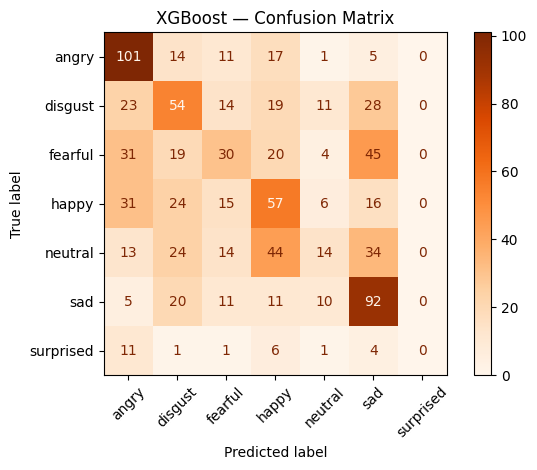

In [ ]:
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
print('=== XGBoost — Evaluación en Test ===')
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=class_names).plot(cmap='Oranges', xticks_rotation=45)
plt.title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.show()
